IMPORTING THE DEPENDENCIES:

In [13]:
#Importing the dependencies:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


DATA COLLECTION AND PROCESSING:

In [14]:
#Loading the data from csv file to pandas dataframe:
df=pd.read_csv("OLX_cars_dataset00.csv")
#Inspecting the first 5 rows of dataframe
df.head()

,Ad ID,Car Name,Make,Model,Year,KM's driven,Price,Fuel,Registration city,Car documents,Assembly,Transmission,Condition,Seller Location,Description,Car Features,Images URL's,Car Profile
0,1079071571,fresh import Passo 2021model,Toyota,Passo,2021,54000,4190000,Petrol,Unregistered,Original,Imported,Automatic,Used,"Airline Avenue, Islamabad","it's 2021 model fresh import, perfect engine s...","ABS, Air Bags, AM/FM Radio, CD Player, Cassett...",['https://images.olx.com.pk/thumbnails/4039460...,https://www.olx.com.pk/item/fresh-import-passo...
1,1080125520,Suzuki ravi,Suzuki,Ravi,2018,95000,1300000,Petrol,Karachi,Original,Local,Manual,Used,"Kahuta, Rawalpindi",Suzuki ravi 2018 col,AM/FM Radio,['https://images.olx.com.pk/thumbnails/4102504...,https://www.olx.com.pk/item/suzuki-ravi-iid-10...
2,1080748789,Suzuki bolan 2015 contact 03112271054,Suzuki,Bolan,2015,50000,800000,Petrol,Karachi,Original,Local,Manual,Used,"Lyari Expressway, Karachi",Suzuki bolan model 2015 reg 2022 ghadi me koi ...,Rear speakers,['https://images.olx.com.pk/thumbnails/4139520...,https://www.olx.com.pk/item/suzuki-bolan-2015-...
3,1076081635,Diahatsu Move 2013,Daihatsu,Move,2013,94000,2155000,Petrol,Lahore,Original,Imported,Automatic,Used,"New Amir Town, Lahore",Move Push start \nHome Used car. \nModel 2013....,"ABS, Air Bags, Air Conditioning, Alloy Rims, A...",['https://images.olx.com.pk/thumbnails/3865337...,https://www.olx.com.pk/item/diahatsu-move-2013...
4,1080812928,Suzuki Swift DLX 2011 miner tuchap,Suzuki,Swift,2011,126544,1440000,Petrol,Karachi,Original,Local,Manual,Used,"Shadman 2, Karachi",Suzuki Swift DLX\nAbS Break 100%\nengine 100%\...,"ABS, Air Conditioning, Alloy Rims, AM/FM Radio...",['https://images.olx.com.pk/thumbnails/4143509...,https://www.olx.com.pk/item/suzuki-swift-dlx-2...


In [15]:
#Getting information about the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9179 entries, 0 to 9178
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Ad ID              9179 non-null   int64 
 1   Car Name           9179 non-null   object
 2   Make               9179 non-null   object
 3   Model              9179 non-null   object
 4   Year               9179 non-null   int64 
 5   KM's driven        9179 non-null   int64 
 6   Price              9179 non-null   int64 
 7   Fuel               9179 non-null   object
 8   Registration city  9179 non-null   object
 9   Car documents      9179 non-null   object
 10  Assembly           9179 non-null   object
 11  Transmission       9179 non-null   object
 12  Condition          9179 non-null   object
 13  Seller Location    9179 non-null   object
 14  Description        9179 non-null   object
 15  Car Features       9179 non-null   object
 16  Images URL's       9179 non-null   object


In [16]:
#Show dataset summary:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ad ID,9179.0,1.079720e+09,2.848393e+06,1.019824e+09,1.080003e+09,1.080543e+09,1.080773e+09,1.080975e+09
Year,9179.0,2.012269e+03,6.043902e+00,1.989000e+03,2.007000e+03,2.013000e+03,2.017000e+03,2.024000e+03
KM's driven,9179.0,9.657042e+04,6.198325e+04,1.000000e+00,5.300000e+04,9.200000e+04,1.250000e+05,5.335280e+05
Price,9179.0,2.036814e+06,1.159302e+06,1.850000e+05,1.025000e+06,1.820000e+06,2.750000e+06,5.000000e+06


In [17]:
#Checking the number of rows and columns:
rows,columns=df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 9179
Number of columns: 18


In [18]:
#Checking the distribution of categorical data:
print(df.Fuel.value_counts())
print(df.Assembly.value_counts())
print(df.Transmission.value_counts()) 

Fuel
Petrol    8984
CNG        193
Hybrid       1
Diesel       1
Name: count, dtype: int64
Assembly
Local       5999
Imported    3180
Name: count, dtype: int64
Transmission
Manual       5633
Automatic    3546
Name: count, dtype: int64


In [19]:
#Print Duplicated rows:
print("Duplicated Rows:")
print(f"Total: {df.duplicated().sum()}")

Duplicated Rows:
Total: 201


Basic Information:

In [20]:
basic_info=pd.DataFrame({
    "Features":df.columns,
    "Missing Values":df.isnull().sum().values,
    "Missing Values %": ((df.isnull().sum().values)/len(df)),
    "Unique Values":df.nunique().values,
    "Data Type":df.dtypes
})
basic_info.reset_index(drop=True)

,Features,Missing Values,Missing Values %,Unique Values,Data Type
0,Ad ID,0,0.000000,8976,int64
1,Car Name,0,0.000000,7970,object
2,Make,0,0.000000,11,object
3,Model,0,0.000000,58,object
4,Year,0,0.000000,27,int64
5,KM's driven,0,0.000000,1598,int64
6,Price,0,0.000000,842,int64
7,Fuel,0,0.000000,4,object
8,Registration city,0,0.000000,61,object
9,Car documents,0,0.000000,2,object


In [21]:
#Drop duplicate values:
df.drop_duplicates(inplace=True)

In [22]:
#Drop columns:
df.drop(columns=["Ad ID","Car Name","Condition","Seller Location","Registration city","Description","Car Features","Images URL's","Car Profile"],inplace=True)

In [23]:
df.shape

(8978, 9)

Graph to Check Distribution of data:

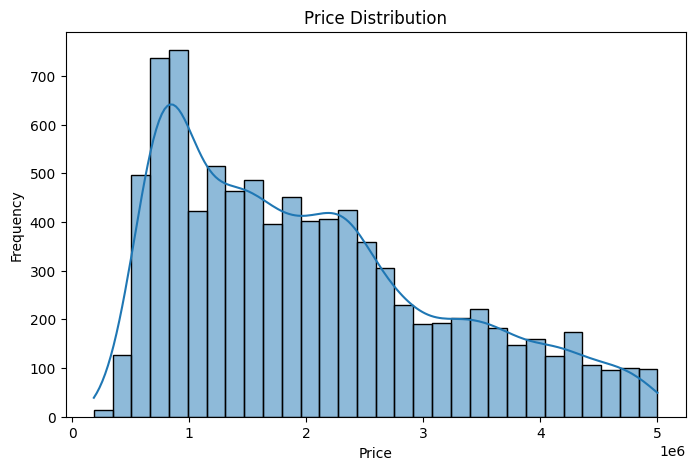

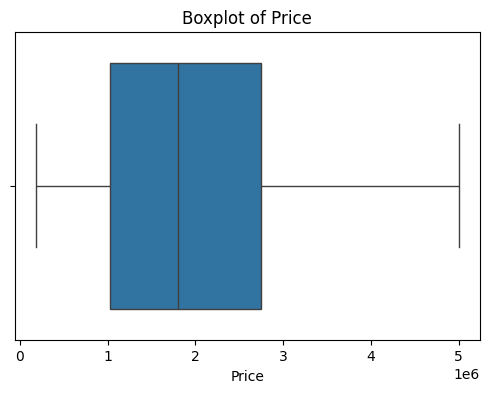

Skewness of Price: 0.6868937551371304
Mean: 2033398.5415460013
Median: 1800000.0
 Data is positively skewed


In [24]:
# Histogram + KDE curve
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True, bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot to visualize outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of Price")
plt.show()

# Calculate skewness
skew_value = df["Price"].skew()
print(f"Skewness of Price: {skew_value}")

# Compare mean and median
mean_price = df["Price"].mean()
median_price = df["Price"].median()
print(f"Mean: {mean_price}")
print(f"Median: {median_price}")

# Interpretation
if -0.5 <= skew_value <= 0.5:
    print(" Data is approximately normal")
elif skew_value > 0.5:
    print(" Data is positively skewed")
else:
    print("Data is negatively skewed")


OUTLIER REMOVAL USING IQR(INTERQUARTILE RANGE):

In [25]:
#Drop rows that are outiers:
Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
filtered_df=df[(df['Price']>=lower_limit) & (df['Price']<=upper_limit)]

In [26]:
df.head()


,Make,Model,Year,KM's driven,Price,Fuel,Car documents,Assembly,Transmission
0,Toyota,Passo,2021,54000,4190000,Petrol,Original,Imported,Automatic
1,Suzuki,Ravi,2018,95000,1300000,Petrol,Original,Local,Manual
2,Suzuki,Bolan,2015,50000,800000,Petrol,Original,Local,Manual
3,Daihatsu,Move,2013,94000,2155000,Petrol,Original,Imported,Automatic
4,Suzuki,Swift,2011,126544,1440000,Petrol,Original,Local,Manual


In [27]:
df.shape

(8978, 9)

FEATURE ENGINEERING:

 Feature Creation:

In [28]:
#Create "Car Age" Feature:
current_year=datetime.now().year
df['Car Age']=current_year-df['Year']

DATA BINNING OR DISCRETIZATION:

In [29]:
n_df=df.copy()

In [30]:
#Crete bins of year column:
bins=[1988,1993,1996,1999,2004,2008,2012,2016,2020,2024]
labels=[1,2,3,4,5,6,7,8,9]
n_df["Year_Range"]=pd.cut(n_df["Year"],bins=bins,labels=labels)
n_df.head()                          


,Make,Model,Year,KM's driven,Price,Fuel,Car documents,Assembly,Transmission,Car Age,Year_Range
0,Toyota,Passo,2021,54000,4190000,Petrol,Original,Imported,Automatic,4,9
1,Suzuki,Ravi,2018,95000,1300000,Petrol,Original,Local,Manual,7,8
2,Suzuki,Bolan,2015,50000,800000,Petrol,Original,Local,Manual,10,7
3,Daihatsu,Move,2013,94000,2155000,Petrol,Original,Imported,Automatic,12,7
4,Suzuki,Swift,2011,126544,1440000,Petrol,Original,Local,Manual,14,6


In [31]:
#Create bins of KM Driven Columns:
bins=[0,30000,60000,90000,120000,150000,180000,210000,240000,270000,300000,330000,360000,390000,410000,440000,470000,500000,533530]
labels=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]
n_df["KM's driven_Range"]=pd.cut(n_df["KM's driven"],bins=bins,labels=labels)
n_df.head()  

,Make,Model,Year,KM's driven,Price,Fuel,Car documents,Assembly,Transmission,Car Age,Year_Range,KM's driven_Range
0,Toyota,Passo,2021,54000,4190000,Petrol,Original,Imported,Automatic,4,9,2
1,Suzuki,Ravi,2018,95000,1300000,Petrol,Original,Local,Manual,7,8,4
2,Suzuki,Bolan,2015,50000,800000,Petrol,Original,Local,Manual,10,7,2
3,Daihatsu,Move,2013,94000,2155000,Petrol,Original,Imported,Automatic,12,7,4
4,Suzuki,Swift,2011,126544,1440000,Petrol,Original,Local,Manual,14,6,5


In [32]:
n_df.isnull().sum()

Make                 0
Model                0
Year                 0
KM's driven          0
Price                0
Fuel                 0
Car documents        0
Assembly             0
Transmission         0
Car Age              0
Year_Range           0
KM's driven_Range    0
dtype: int64

Converting categorical bin labels into integer format for modeling


In [33]:
cols=["Year_Range","KM's driven_Range"]
for column in cols:
    n_df[column]=n_df[column].astype("int32")

In [34]:
#Checking corelations of new columns with price column
n_df.select_dtypes(["int","float"]).corr()

,Year,KM's driven,Price,Car Age,Year_Range,KM's driven_Range
Year,1.000000,-0.379242,0.679646,-1.000000,0.982791,-0.383812
KM's driven,-0.379242,1.000000,-0.186703,0.379242,-0.379149,0.989875
Price,0.679646,-0.186703,1.000000,-0.679646,0.671417,-0.194022
Car Age,-1.000000,0.379242,-0.679646,1.000000,-0.982791,0.383812
Year_Range,0.982791,-0.379149,0.671417,-0.982791,1.000000,-0.383337
KM's driven_Range,-0.383812,0.989875,-0.194022,0.383812,-0.383337,1.000000


CORELATION HEATMAP:

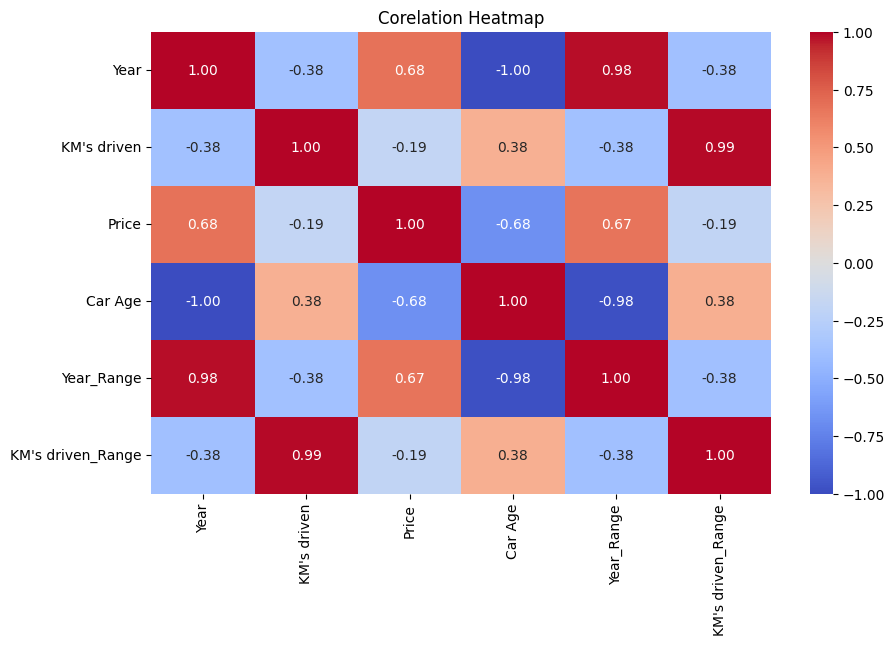

In [35]:
corr_matrix=n_df.select_dtypes(["int","float"]).corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Corelation Heatmap")
plt.show()

PRICE VS CAR AGE (SCATTER PLOT)

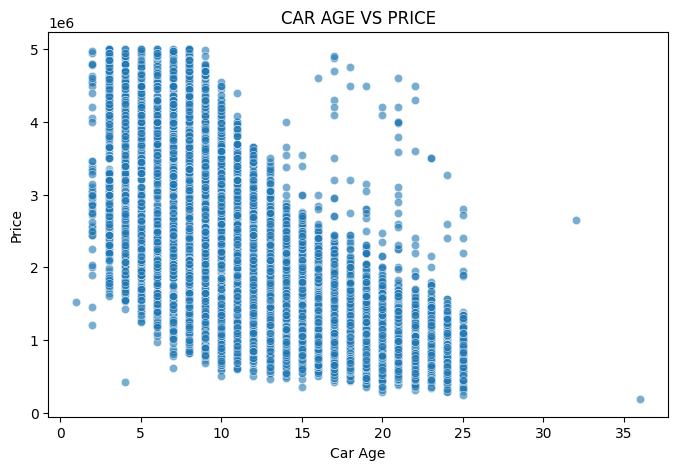

In [36]:
#How car age affect the price
plt.figure(figsize=(8,5))
sns.scatterplot(x="Car Age",y="Price",data=n_df,alpha=0.6)
plt.title("CAR AGE VS PRICE")
plt.show()

PRICE VS KM DRIVEN (SCATTERPLOT)

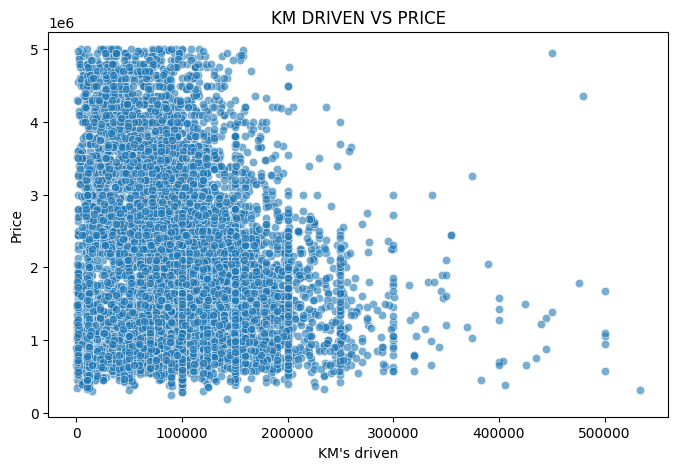

In [37]:
#Check the relation of mileage and price:
plt.figure(figsize=(8,5))
sns.scatterplot(x="KM's driven",y="Price",data=n_df,alpha=0.6)
plt.title("KM DRIVEN VS PRICE")
plt.show()

AVERAGE PRICE BY FUEL TYPE (BARPLOT):

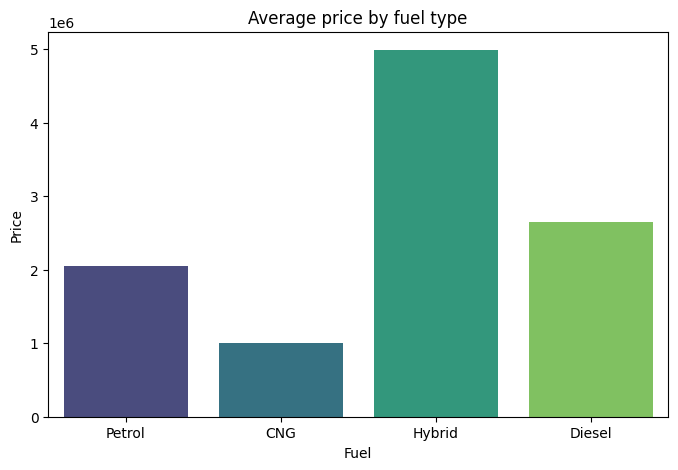

In [38]:
#Which fuel type is expensive or cheap:
plt.figure(figsize=(8,5))
sns.barplot(x="Fuel",y="Price",data=n_df,estimator=np.mean, hue="Fuel",legend=False,errorbar=None,palette="viridis")
plt.title("Average price by fuel type")
plt.show()
                

AVERAGE PRICE BY MAKE/BRAND (BAR PLOT)

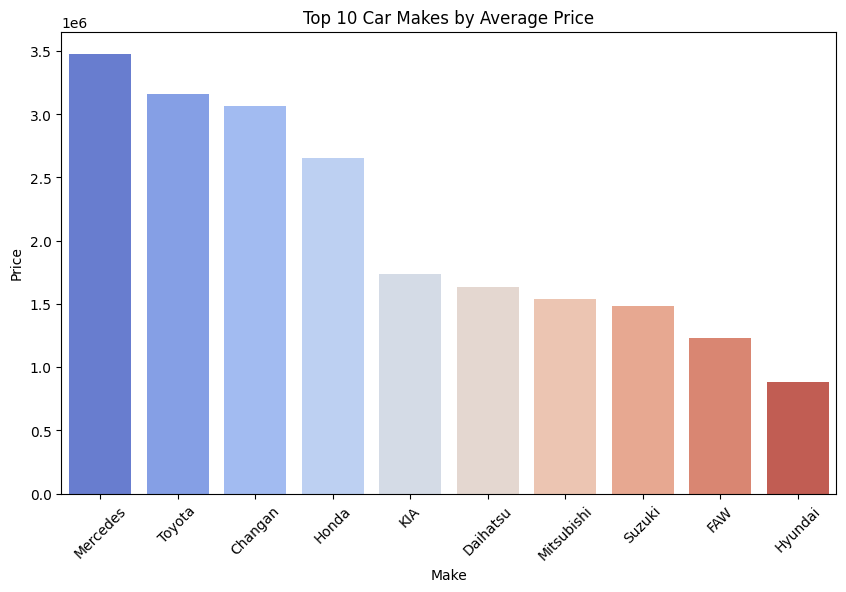

In [39]:
#Which brand of car is more expensive( top 10)
plt.figure(figsize=(10,6))
top_makes=n_df.groupby("Make")["Price"].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="Make",y="Price",data=top_makes,hue="Make",legend=False,dodge=False,palette="coolwarm")
plt.title("Top 10 Car Makes by Average Price")
plt.xticks(rotation=45)
plt.show()

TRANSMISSION VS PRICE (BOX PLOT):

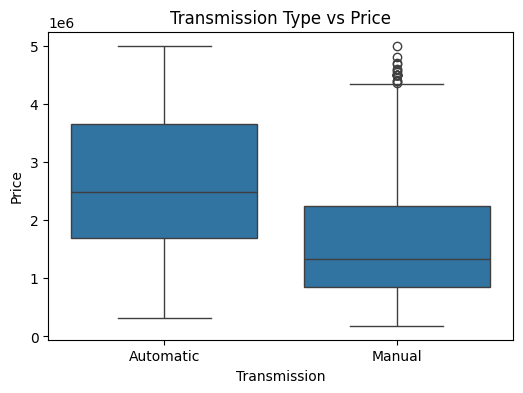

In [40]:
#Check the price distribution of auto and manual cars:
plt.figure(figsize=(6,4))
sns.boxplot(x="Transmission",y="Price",data=n_df)
plt.title("Transmission Type vs Price")
plt.show()

MODEL BUILDING:

In [41]:
#import libraries:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

1. TRAIN TEST SPLIT:

In [42]:
x=n_df.drop("Price", axis=1)
y=n_df["Price"]
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.15,random_state=42)    

In [43]:
print(f"Shape of X_train:{x_train.shape}")
print(f"Shape of X_test:{x_test.shape}")
print(f"Shape of Y_train:{y_train.shape}")
print(f"Shape of Y_test:{y_test.shape}")

Shape of X_train:(7631, 11)
Shape of X_test:(1347, 11)
Shape of Y_train:(7631,)
Shape of Y_test:(1347,)


In [44]:
x_train

,Make,Model,Year,KM's driven,Fuel,Car documents,Assembly,Transmission,Car Age,Year_Range,KM's driven_Range
5291,Suzuki,Every,2023,50000,Petrol,Original,Imported,Manual,2,9,2
7834,Daihatsu,Cuore,2008,95000,Petrol,Original,Local,Manual,17,5,4
8877,Honda,City IVTEC,2014,92000,Petrol,Original,Local,Manual,11,7,4
3325,Suzuki,Mehran VXR,2008,70000,CNG,Original,Local,Manual,17,5,3
3492,Honda,City IVTEC,2012,76000,Petrol,Original,Local,Automatic,13,6,3
...,...,...,...,...,...,...,...,...,...,...,...
5830,Suzuki,Mehran VXR,2017,75000,Petrol,Original,Local,Manual,8,8,3
5273,Honda,City IVTEC,2014,123000,Petrol,Original,Local,Manual,11,7,5
5476,Honda,City Aspire,2021,30000,Petrol,Original,Local,Automatic,4,9,1
861,Hyundai,Santro,2003,121000,Petrol,Original,Local,Manual,22,4,5


In [45]:
y_train

5291    2725000
7834     875000
8877    2950000
3325     539000
3492    2500000
         ...   
5830    1125000
5273    2800000
5476    4300000
861      925000
7408    3800000
Name: Price, Length: 7631, dtype: int64

2. CREATE COLUMN TRANSFORMERS:

In [46]:
ct1=ColumnTransformer(transformers=[
    ("oneHotEncoder",OneHotEncoder(sparse_output=False,drop="first",handle_unknown="ignore"),[0,1,4,5,6,7])],remainder="passthrough")

ct2=ColumnTransformer(transformers=[
    ("minMaxScaler",MinMaxScaler(),[2,3,8,9,10])],remainder="passthrough")

ct3=ColumnTransformer(transformers=[
    ("quantileTransformer",QuantileTransformer(output_distribution="normal"),slice(0,None))])

ct4=RandomForestRegressor()
     

3. CREATE PIPELINE:

In [47]:
pipeline=Pipeline([
    ("Encoder", ct1),
    ("Scaler", ct2),
    ("Normalizer", ct3),
    ("Model", ct4)
])    

In [48]:
pipeline.fit(x_train,y_train)
y_pred= pipeline.predict(x_test)
#Accuracy Measure:
mae = mean_absolute_error(y_test, y_pred)  
average_price = y_test.mean()
relative_error = mae / average_price
accuracy_percent = (1 - relative_error) * 100
print("Mean Absolute Error:", mae)
print("Approximate Accuracy (%):", accuracy_percent)

C:\Users\ridai\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Mean Absolute Error: 184287.64285734142
Approximate Accuracy (%): 91.13958548380053


4. IMPORT MODEL INTO PICKLE:



In [51]:
import pickle
model_path = "../models/pipeline.pkl"
dataset_path = "../datasets/dataset.csv"

pickle.dump(pipeline, open(model_path, "wb"))
pickle.dump(n_df, open(dataset_path, "wb"))


In [57]:
df['Make'].unique()

array(['Toyota', 'Suzuki', 'Daihatsu', 'Honda', 'Hyundai', 'Mitsubishi',
       'KIA', 'Changan', 'FAW', 'Mercedes', 'Chevrolet'], dtype=object)

In [58]:
df['Model'].unique()

array(['Passo', 'Ravi', 'Bolan', 'Move', 'Swift', 'Wagon R', 'Mira',
       'City IDSI', 'Cultus VXR', 'Every', 'Corolla XLI', 'Baleno',
       'City Vario', 'Terios Kid', 'Civic Prosmetic', 'City IVTEC',
       'Santro', 'Corrolla Altis', 'City Aspire', 'Mehran VXR', 'Cuore',
       'Pajero Mini', 'Picanto', 'Alto', 'Karvaan', 'X-PV', 'Hijet',
       'Ek Wagon', 'Altis Grande', 'E Class', 'Yaris', 'Lancer',
       'Corolla GLI', 'Joy', 'Civic Oriel', 'Classic', 'Spectra', 'V2',
       'Minicab Bravo', 'Corolla Assista', 'Alsvin', 'C Class', 'Minica',
       'Exclusive', 'Civic VTi', 'Cervo', 'Sportage', 'Corolla Axio',
       'Every Wagon', 'Liana', 'Civic EXi', 'Surf', 'Mehran VX',
       'Civic VTi Oriel', 'Khyber', 'Cultus VXL', 'Prius', 'ISIS'],
      dtype=object)

In [60]:
df['Fuel'].unique()

array(['Petrol', 'CNG', 'Hybrid', 'Diesel'], dtype=object)

In [61]:
df['Assembly'].unique()

array(['Imported', 'Local'], dtype=object)

In [62]:
df['Transmission'].unique()

array(['Automatic', 'Manual'], dtype=object)

In [64]:
df['Car documents'].unique()

array(['Original', 'Duplicate'], dtype=object)